# BMEG 424/524: Convolutional Neural Network for DNA to Expression Modelling

You are doing similar, but not exactly the same, things in A5. Most of the code here will not be directly translatable - but could be adapted for some purposes if you needed.

> The data in this tutorial is simulated. In A5 you use MPRA/MPRA-like data.

## Biological Background
Briefly, DNA contains within it the information to *regulate* genes via cis-regulatory regions like promotors, enhancers, and untranslated regions. Through changes in 3D-chromosome confirmation and specific motifs which can enable interaction with transcription factors.

![](https://encyclopedia.pub/media/item_content/202307/64a22dbf54290genes-14-01226-g001.png)

Understanding the interplay between motifs, and putative TF-binding, provides one layer of mechanism which drive transcription.

## Technical Background
We can at a very simplistic level imagine a function $f$ which takes input DNA sequences and outputs a prediction of gene expresion (assuming the input represents some regulatory context). Training such a model requires modifying the regulatory-regions of a gene and measuring its gene expression (e.g. MPRA).

![](https://ars.els-cdn.com/content/image/1-s2.0-S0888754315300082-gr2.jpg)

Numerous models attempt to predict this sequence-to-expression function *f* - some models better than others.

### Convolutional Neural Networks
CNNs learn from *spatial* information. Intutively, one might be aware of the application of CNNs applied for classifying images (e.g. cat vs dog). DNA can similarly be processed by a CNN using 1-dimensional kernals - analogous to a "flat" image. Here,

![](https://miro.medium.com/1*WVVVA8dV58YJ63OLm-lpsw.png)

> Here the "input signal" would be 4xL, thus the first layer will take input 4 channels (one for each one-hot encoding layer/nucleotide).

**How does a CNN actually learn?** Each kernal, within each layer, is initially filled with random values. As the CNN is trained, these weights are gradually updated to focus on patterns (e.g. motifs) that inform predictability.

![](https://ars.els-cdn.com/content/image/3-s2.0-B9780323901987000069-f02-04-9780323901987.jpg)


# Data preperation

In this tutorial we generate a synthetic dataset of random DNA with artifical motifs and corresponding gene expression values.



In [1]:
# imports
import math, random
import numpy as np
import torch
import torch.nn as nn  # neural networks
import torch.nn.functional as F  # functions for neural networks
from torch.utils.data import Dataset, DataLoader  # pytorch dataset objects
import matplotlib.pyplot as plt  # plotting

# set seed
def seed_all(seed: int = 0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_all()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {DEVICE.upper()}")

Using CUDA


In [2]:
# helpers for random DNA sequence generation
BASES = "ACGT"
B2I = {b: i for i, b in enumerate(BASES)}  # A=0,C=1,G=2,T=3

# convert DNA to one-hot encoding
def one_hot_encode(seq: str) -> np.ndarray:
    """Return (4, L) float32 one-hot encoding."""
    L = len(seq)
    x = np.zeros((4, L), dtype=np.float32)
    for j, ch in enumerate(seq):
        x[B2I[ch], j] = 1.0
    return x

# generate a random DNA sequence of length L
def random_dna(L: int) -> str:
    return "".join(random.choice(BASES) for _ in range(L))

# insert a motif-string into the provided DNA sequence to "simulate" presence of motif
def embed_motif(seq: str, motif: str) -> str:
    """Insert motif at a random position (single insertion)."""
    L = len(seq)
    m = len(motif)
    i = random.randint(0, L - m)
    return seq[:i] + motif + seq[i+m:]

In [3]:
class SyntheticSeqExpressionDataset(Dataset):
    """
    Each sequence optionally gets planted motifs.
    Expression is a noisy function of motif presence.
    Returns:
      X: (4, L) one-hot  -- DNA sequence
      y: scalar float -- expression cause by corresponding sequence x
    """
    def __init__(
        self,
        n: int = 20000,
        seq_len: int = 200,
        motifs=("CACGTG", "TTGACA", "TATAAA"),
        motif_weights=(2.0, 1.5, 1.0),
        p_insert=(0.5, 0.3, 0.5),
        noise_sd: float = 0.4,
    ):
        assert len(motifs) == len(motif_weights) == len(p_insert)
        self.seq_len = seq_len

        self.seqs = []
        self.expr = []

        # generate N DNA sequences
        for _ in range(n):
            s = random_dna(seq_len)

            present = []
            # add motifs at a certain probability
            for mot, p in zip(motifs, p_insert):
                if random.random() < p:
                    s = embed_motif(s, mot)
                    present.append(1.0)
                else:
                    present.append(0.0)

            y = 0.0
            # generate expression based on motif existance in sequence + noise
            for w, pr in zip(motif_weights, present):
                y += w * pr
            y += np.random.normal(0.0, noise_sd)

            # stabilize and keep positive-ish
            y = math.log1p(math.exp(y))  # softplus

            self.seqs.append(s)
            self.expr.append(float(y))

        self.expr = np.array(self.expr, dtype=np.float32)

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        x = one_hot_encode(self.seqs[idx])  # (4, L)
        y = self.expr[idx]
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.float32)

In [4]:
## load datasets
seq_len =  ## complete
n_samples =  ## complete
ds = SyntheticSeqExpressionDataset(n=n_samples, seq_len=seq_len)

idx = np.arange(len(ds))
np.random.shuffle(idx)
n_train = int(0.85 * len(ds))
train_idx, val_idx = idx[:n_train], idx[n_train:]

train_ds = torch.utils.data.Subset(ds, train_idx.tolist())
val_ds = torch.utils.data.Subset(ds, val_idx.tolist())

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=512, shuffle=False, num_workers=0, pin_memory=True)

len(train_ds), len(val_ds)

(21250, 3750)

In [6]:
class SeqCNN(nn.Module):
    def __init__(self, n_filters: int, kernel_size: int, dropout: float = 0.1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=4, out_channels=n_filters, kernel_size=kernel_size, padding=0)
        self.bn1 = nn.BatchNorm1d(n_filters)

        self.conv2 = nn.Conv1d(in_channels=n_filters, out_channels=n_filters, kernel_size=7, padding=0)
        self.bn2 = nn.BatchNorm1d(n_filters)

        self.dropout = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(n_filters, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        # x: (B, 4, L)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))

        # global max pool over length dimension
        x = torch.max(x, dim=-1).values  # (B, n_filters)

        x = self.dropout(x)
        x = self.head(x).squeeze(-1)     # (B,)
        return x

nfilters =  ## complete
ksize =  ## complete
model = SeqCNN(n_filters=nfilters, kernel_size=ksize, dropout=0.1).to(DEVICE)
model

SeqCNN(
  (conv1): Conv1d(4, 64, kernel_size=(15,), stride=(1,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(64, 64, kernel_size=(7,), stride=(1,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [7]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss, n = 0.0, 0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)

        pred = model(X)
        loss = F.mse_loss(pred, y)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        bs = X.size(0)
        total_loss += float(loss.item()) * bs
        n += bs
    return total_loss / n

@torch.no_grad()
def eval_mse(model, loader):
    model.eval()
    total, n = 0.0, 0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        pred = model(X)
        ## PICK ONE
        # total += float(F.mse_loss(pred, y, reduction="sum").item())
        # total += float(F.cross_entropy(pred, y, reduction="sum").item())
        n += X.size(0)
    return total / n

opt = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)

trainloss, valloss = [], []
for epoch in range(1, 18):
    tr = train_one_epoch(model, train_loader, opt)
    va = eval_mse(model, val_loader)
    trainloss.append(tr)
    valloss.append(va)
    print(f"epoch {epoch:02d} | train MSE {tr:.4f} | val MSE {va:.4f}")

epoch 01 | train MSE 1.2463 | val MSE 0.8157
epoch 02 | train MSE 0.7777 | val MSE 0.6729
epoch 03 | train MSE 0.6918 | val MSE 0.7499
epoch 04 | train MSE 0.6193 | val MSE 0.6363
epoch 05 | train MSE 0.6469 | val MSE 0.5397
epoch 06 | train MSE 0.5858 | val MSE 0.5216
epoch 07 | train MSE 0.5218 | val MSE 0.4838
epoch 08 | train MSE 0.5077 | val MSE 0.5234
epoch 09 | train MSE 0.4824 | val MSE 0.4796
epoch 10 | train MSE 0.4803 | val MSE 0.5330
epoch 11 | train MSE 0.4551 | val MSE 0.5723
epoch 12 | train MSE 0.5393 | val MSE 0.4767
epoch 13 | train MSE 0.4482 | val MSE 0.4617
epoch 14 | train MSE 0.4587 | val MSE 0.5406
epoch 15 | train MSE 0.4379 | val MSE 0.6171
epoch 16 | train MSE 0.5115 | val MSE 0.5469
epoch 17 | train MSE 0.4164 | val MSE 0.4754


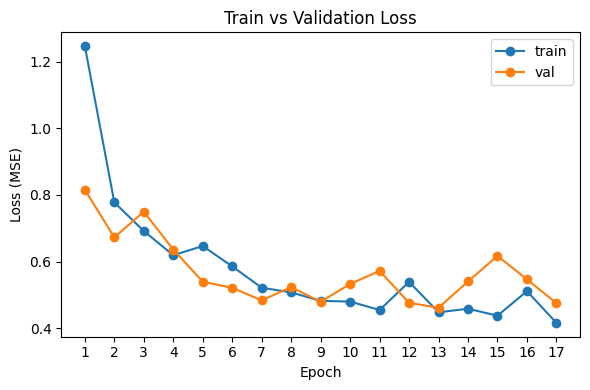

In [12]:
epochs = list(range(1, len(trainloss)+1))
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(epochs, trainloss, marker="o", label="train")
ax.plot(epochs, valloss, marker="o", label="val")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (MSE)")
ax.set_title("Train vs Validation Loss")
ax.set_xticks(epochs)
ax.legend()
fig.tight_layout()

**What did our model learn? Did it learn the motifs?**

In [13]:
@torch.no_grad()
def conv1_kernels_to_pwm_like(conv1: nn.Conv1d) -> np.ndarray:
    """
    conv1.weight: (F, 4, K)
    Convert to a PWM-like matrix by softmax over bases at each position.
    Returns: (F, 4, K) where columns sum to 1 across A/C/G/T (axis=1).
    """
    W = conv1.weight.detach().cpu()   # (F, 4, K)
    P = torch.softmax(W, dim=1)       # (F, 4, K)
    return P.numpy()

## function to determine on average, how "large" is the output from each kernal on the VALIDATION data
@torch.no_grad()
def conv1_filter_importance(model, loader, max_batches: int = 25) -> np.ndarray:
    """
    Importance proxy: mean max activation per filter after conv1+relu.
    """
    model.eval()
    scores = None
    n_seen = 0

    for b, (X, y) in enumerate(loader):
        if b >= max_batches:
            break
        X = X.to(DEVICE)

        a = F.relu(model.bn1(model.conv1(X)))         # (B, F, L')
        s = torch.max(a, dim=-1).values.mean(dim=0)   # (F,)

        scores = s if scores is None else (scores + s)
        n_seen += 1

    scores = (scores / max(1, n_seen)).detach().cpu().numpy()
    return scores

pwm_like = conv1_kernels_to_pwm_like(model.conv1)
scores = conv1_filter_importance(model, val_loader, max_batches=25)

pwm_like.shape, scores.shape

((64, 4, 15), (64,))

Plot the top K active kernals (from the first layer)

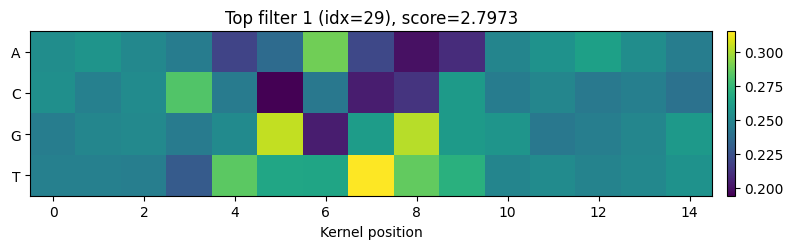

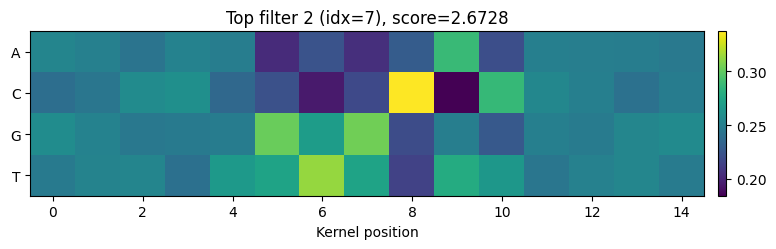

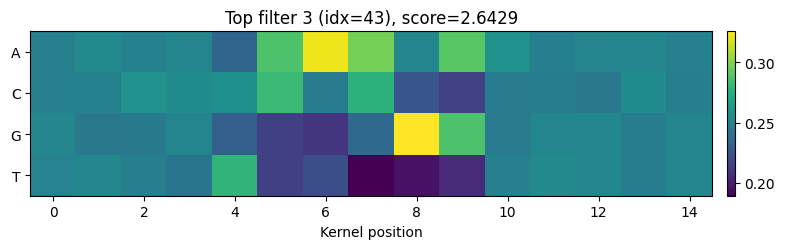

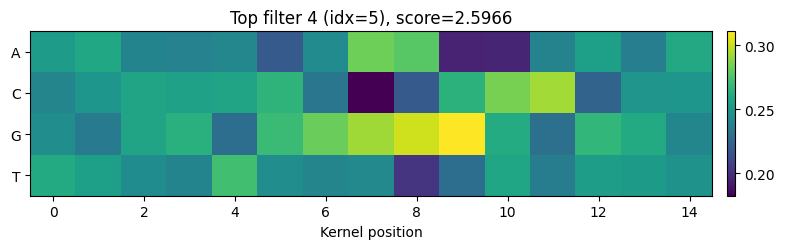

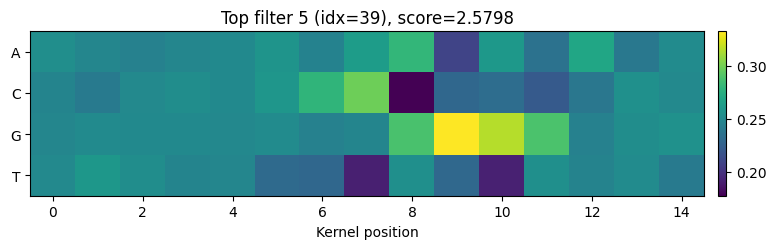

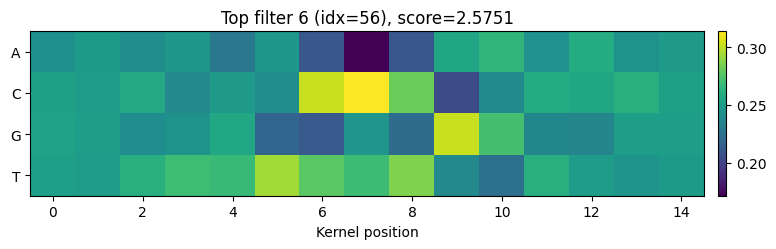

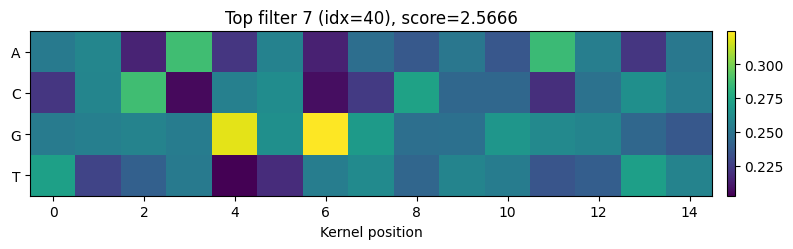

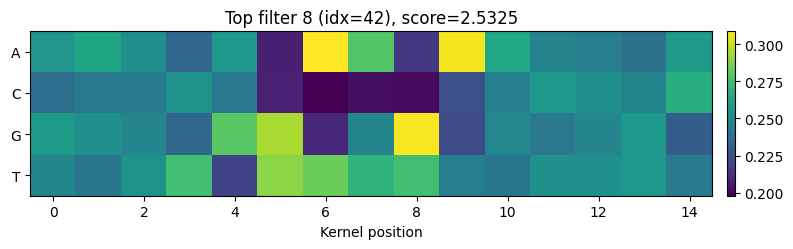

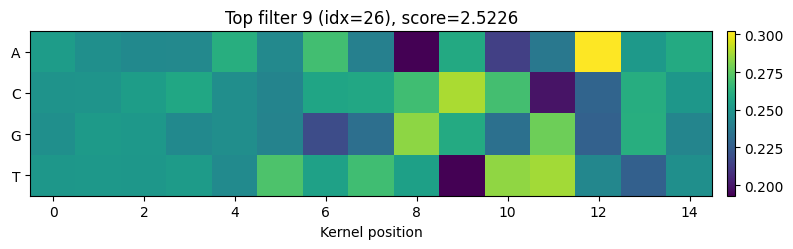

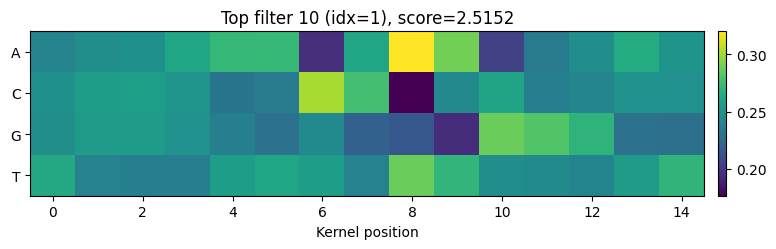

In [16]:
def plot_kernel_pwm(pwm_like: np.ndarray, filt_idx: int, title: str = None):
    """
    pwm_like: (F, 4, K)
    Heatmap with rows A,C,G,T and columns positions.
    """
    mat = pwm_like[filt_idx]  # (4, K)

    fig, ax = plt.subplots(figsize=(8, 2.6))
    im = ax.imshow(mat, aspect="auto", interpolation="nearest")
    ax.set_yticks(range(4))
    ax.set_yticklabels(list(BASES))
    ax.set_xlabel("Kernel position")
    ax.set_title(title or f"conv1 filter {filt_idx}: PWM-like base preferences")
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    fig.tight_layout()
    plt.show()

def plot_top_k_kernels(pwm_like: np.ndarray, scores: np.ndarray, k: int = 6):
    top = np.argsort(scores)[::-1][:k]
    for i, f in enumerate(top):
        plot_kernel_pwm(
            pwm_like,
            int(f),
            title=f"Top filter {i+1} (idx={int(f)}), score={scores[int(f)]:.4f}"
        )

plot_top_k_kernels(pwm_like, scores, k=10)

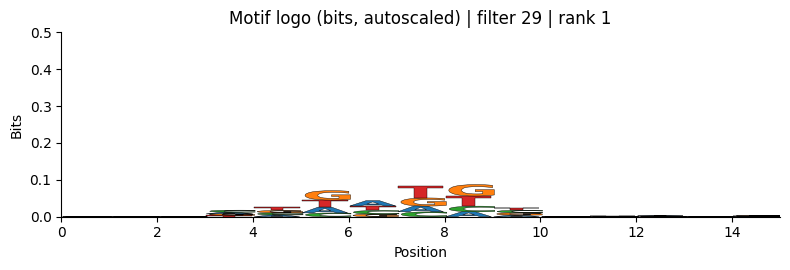

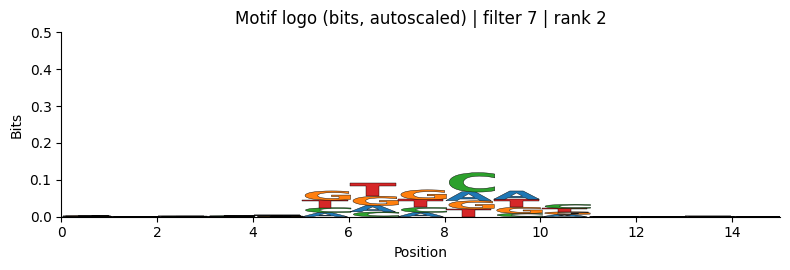

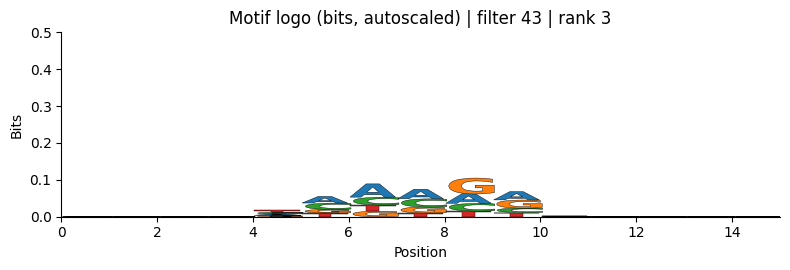

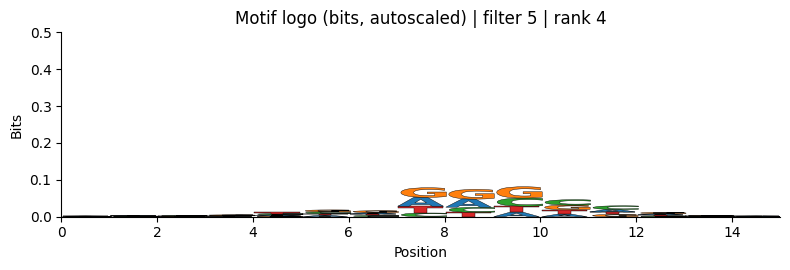

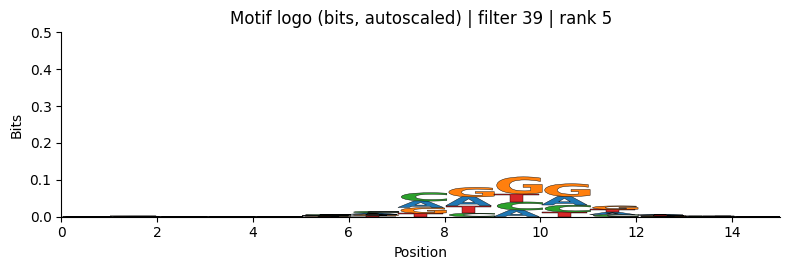

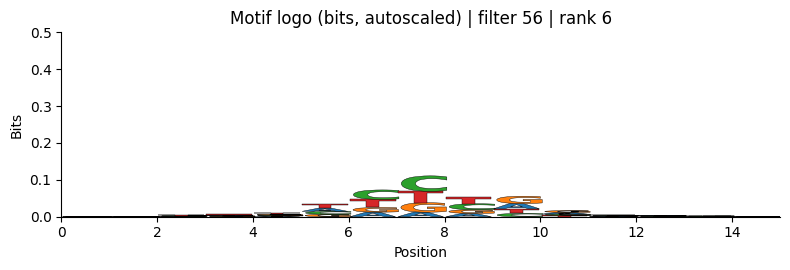

In [17]:
## ATTEMPTED TO VISUALIZE LOGOS WITH CHATGPT

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.textpath import TextPath
from matplotlib.patches import PathPatch
from matplotlib.transforms import Affine2D
from matplotlib.font_manager import FontProperties

fp = FontProperties(family="DejaVu Sans", weight="bold")

def softmax_np(x, axis=0):
    x = x - np.max(x, axis=axis, keepdims=True)
    ex = np.exp(x)
    return ex / np.sum(ex, axis=axis, keepdims=True)

def weights_to_pwm_like(W_4xL: np.ndarray, temperature: float = 0.5) -> np.ndarray:
    """
    Convert raw weights (4, L) to probabilities via softmax over bases.
    temperature < 1 sharpens (higher information); temperature > 1 flattens.
    """
    W = W_4xL.astype(np.float64) / max(1e-8, float(temperature))
    P = softmax_np(W, axis=0)
    return P.astype(np.float32)

def pwm_to_bits_heights(pwm_4xL: np.ndarray, pseudocount: float = 1e-6) -> np.ndarray:
    """
    pwm_4xL: (4, L), columns sum to 1.
    Returns heights (4, L) in bits; column sum = information content (0..2).
    """
    P = np.clip(pwm_4xL.astype(np.float64), pseudocount, 1.0)
    P = P / P.sum(axis=0, keepdims=True)
    H = -(P * np.log2(P)).sum(axis=0)     # entropy
    I = np.clip(2.0 - H, 0.0, 2.0)        # information
    heights = P * I[None, :]
    return heights.astype(np.float32)

def draw_sequence_logo(heights_4xL: np.ndarray, ax=None, title: str = None, colors=None):
    """
    Draw stacked-letter sequence logo; autoscale y-limit to data.
    heights_4xL in A,C,G,T order.
    """
    if colors is None:
        colors = {"A": "#1f77b4", "C": "#2ca02c", "G": "#ff7f0e", "T": "#d62728"}

    if ax is None:
        fig, ax = plt.subplots(figsize=(max(6, 0.35 * heights_4xL.shape[1]), 2.8))

    L = heights_4xL.shape[1]
    col_sums = heights_4xL.sum(axis=0)
    ymax = float(max(0.5, col_sums.max() * 1.15))   # autoscale; floor avoids tiny look
    ax.set_xlim(0, L)
    ax.set_ylim(0, ymax)
    ax.set_xlabel("Position")
    ax.set_ylabel("Bits")
    if title is not None:
        ax.set_title(title)

    letters = ["A", "C", "G", "T"]

    for j in range(L):
        col = heights_4xL[:, j]
        order = np.argsort(col)  # small -> large
        y0 = 0.0
        for idx in order:
            h = float(col[idx])
            if h <= 1e-6:
                continue

            letter = letters[idx]
            tp = TextPath((0, 0), letter, size=1, prop=fp)
            bb = tp.get_extents()
            w = bb.width if bb.width > 0 else 1.0
            h0 = bb.height if bb.height > 0 else 1.0

            # scale to width ~1 and height = h (in bits units)
            sx = 0.95 / w
            sy = h / h0

            trans = Affine2D().scale(sx, sy).translate(j + 0.02, y0)
            patch = PathPatch(
                tp,
                transform=trans + ax.transData,
                facecolor=colors[letter],
                edgecolor="black",
                linewidth=0.3,
            )
            ax.add_patch(patch)
            y0 += h

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    return ax

# === Use on conv1 filters ===
# If you used pwm_like already (from softmax), you can keep it.
# Better: compute logo from *raw conv1 weights* with temperature sharpening.
W = model.conv1.weight.detach().cpu().numpy()   # (F, 4, K)
top_filters = np.argsort(scores)[::-1][:6]

for rank, f in enumerate(top_filters, start=1):
    Wf = W[int(f)]                                # (4, K) raw weights
    P = weights_to_pwm_like(Wf, temperature=0.5)  # sharpen; try 0.25 if still flat
    heights = pwm_to_bits_heights(P)

    fig, ax = plt.subplots(figsize=(8, 2.8))
    draw_sequence_logo(
        heights,
        ax=ax,
        title=f"Motif logo (bits, autoscaled) | filter {int(f)} | rank {rank}"
    )
    plt.show()

    # ("CACGTG", "TTGACA", "TATAAA"),